# 📊 Dataset 2 – USDA Food Environment Atlas
## Data Exploration | Milestone 2

**Dataset:** USDA Food Environment Atlas (`FoodEnvironmentAtlas.xls`)  
**Sheet used:** `STORES`  
**Scope:** 3,143 US counties (all 50 states + DC)  
**Granularity:** County-level food retail infrastructure metrics

---

### 🗺️ Research Context
This dataset is used to explore **food access inequality** across US counties.  
We examine how the density of grocery stores, supercenters, convenience stores, SNAP retailers, and WIC outlets varies geographically — and construct a composite *Food Infrastructure Index* to quantify access disparities.

---

## 1. Data Collection

### Source
**USDA Economic Research Service – Food Environment Atlas**  
URL: https://www.ers.usda.gov/data-products/food-environment-atlas/

### Collection Method
The USDA ERS publishes the Food Environment Atlas as an official government data product, updated periodically (most recent version covers data through 2016–2017). The file is downloaded directly from the USDA ERS portal and stored in Google Drive for reproducibility.

### Why this source?
- ✅ **Official / authoritative**: Published by the US federal government (USDA ERS)
- ✅ **Multi-sheet**: Contains 10+ thematic sheets (STORES, RESTAURANTS, HEALTH, SOCIOECONOMIC, etc.)
- ✅ **County-level granularity**: 3,143 unique FIPS-coded counties
- ✅ **Directly relevant** to research questions on food access and nutrition inequality

### Why not an API?
The USDA ERS does not provide a real-time API for this dataset. The Food Environment Atlas is a compiled research product updated on a multi-year cycle, making a static download the appropriate and only available method.

### ⚠️ Data Ethics & Limitations
> - **Temporal lag**: Most variables reflect 2011–2017 data; conditions may have changed significantly post-COVID.
> - **Aggregation bias**: County averages mask intra-county variation (urban vs. rural sub-areas).
> - **Missing data**: Small/remote counties (e.g., Alaska boroughs) have missing WIC and SNAP records — likely due to zero or unrecorded operations, not random missingness.
> - **Social bias**: Density metrics (stores per 1,000 people) may under-represent Indigenous and rural communities where population denominators are small but geographic coverage is large.


In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
FE_PATH = "/content/drive/MyDrive/data mining/FoodEnvironmentAtlas.xls"

import pandas as pd

xls = pd.ExcelFile(FE_PATH)

xls.sheet_names

['Read_Me',
 ' Variable List',
 'Supplemental Data - County',
 'Supplemental Data - State',
 'ACCESS',
 'STORES',
 'RESTAURANTS',
 'ASSISTANCE',
 'INSECURITY',
 'TAXES',
 'LOCAL',
 'HEALTH',
 'SOCIOECONOMIC']

We focus on the `STORES` sheet, which contains per-1,000-population densities of grocery, supercenter, convenience, SNAP, and WIC stores by county.

**Key columns:**
| Column | Description |
|--------|-------------|
| `FIPS` | Federal county identifier (5-digit) |
| `GROCPTH16` | Grocery stores per 1,000 pop (2016) |
| `SUPERCPTH16` | Supercenters per 1,000 pop (2016) |
| `CONVSPTH16` | Convenience stores per 1,000 pop (2016) |
| `SNAPSPTH17` | SNAP-authorized retailers per 1,000 pop (2017) |
| `WICSPTH16` | WIC-authorized outlets per 1,000 pop (2016) |

Raw data snapshot before cleaning

In [51]:
stores = pd.read_excel(
    FE_PATH,
    sheet_name="STORES"
)

stores.head()

,FIPS,State,County,GROC11,GROC16,PCH_GROC_11_16,GROCPTH11,GROCPTH16,PCH_GROCPTH_11_16,SUPERC11,...,PCH_SNAPS_12_17,SNAPSPTH12,SNAPSPTH17,PCH_SNAPSPTH_12_17,WICS11,WICS16,PCH_WICS_11_16,WICSPTH11,WICSPTH16,PCH_WICSPTH_11_16
0,1001,AL,Autauga,5,3,-40.000000,0.090581,0.054271,-40.085748,1,...,19.376392,0.674004,0.804747,19.397900,5.0,5.0,0.000000,0.090567,0.090511,-0.061543
1,1003,AL,Baldwin,27,29,7.407407,0.144746,0.139753,-3.449328,6,...,36.927711,0.725055,0.890836,22.864524,26.0,28.0,7.692307,0.139380,0.134802,-3.284727
2,1005,AL,Barbour,6,4,-33.333333,0.219370,0.155195,-29.254287,0,...,3.349282,1.280590,1.424614,11.246689,7.0,6.0,-14.285714,0.255942,0.232387,-9.203081
3,1007,AL,Bibb,6,5,-16.666667,0.263794,0.220916,-16.254289,1,...,11.794872,0.719122,0.801423,11.444711,6.0,5.0,-16.666666,0.263771,0.221474,-16.035471
4,1009,AL,Blount,7,5,-28.571429,0.121608,0.086863,-28.571429,1,...,5.701754,0.657144,0.692374,5.361034,8.0,8.0,0.000000,0.139000,0.139089,0.064332


In [52]:
stores.shape
stores.columns

Index(['FIPS', 'State', 'County', 'GROC11', 'GROC16', 'PCH_GROC_11_16',
       'GROCPTH11', 'GROCPTH16', 'PCH_GROCPTH_11_16', 'SUPERC11', 'SUPERC16',
       'PCH_SUPERC_11_16', 'SUPERCPTH11', 'SUPERCPTH16', 'PCH_SUPERCPTH_11_16',
       'CONVS11', 'CONVS16', 'PCH_CONVS_11_16', 'CONVSPTH11', 'CONVSPTH16',
       'PCH_CONVSPTH_11_16', 'SPECS11', 'SPECS16', 'PCH_SPECS_11_16',
       'SPECSPTH11', 'SPECSPTH16', 'PCH_SPECSPTH_11_16', 'SNAPS12', 'SNAPS17',
       'PCH_SNAPS_12_17', 'SNAPSPTH12', 'SNAPSPTH17', 'PCH_SNAPSPTH_12_17',
       'WICS11', 'WICS16', 'PCH_WICS_11_16', 'WICSPTH11', 'WICSPTH16',
       'PCH_WICSPTH_11_16'],
      dtype='object')

 Column Selection
We retain only the most recent per-1,000-population density columns (suffix `PTH`) and drop the 30+ historical/percent-change columns.  
**Rationale:** Percent-change columns (`PCH_*`) are derived features that would introduce multicollinearity. We keep the 2016/2017 snapshot as the target year.

In [53]:
stores_clean = stores[[
    "FIPS",
    "State",
    "County",
    "GROCPTH16",
    "SUPERCPTH16",
    "CONVSPTH16",
    "SNAPSPTH17",
    "WICSPTH16"
]].copy()

stores_clean.head()

,FIPS,State,County,GROCPTH16,SUPERCPTH16,CONVSPTH16,SNAPSPTH17,WICSPTH16
0,1001,AL,Autauga,0.054271,0.018090,0.560802,0.804747,0.090511
1,1003,AL,Baldwin,0.139753,0.033733,0.568650,0.890836,0.134802
2,1005,AL,Barbour,0.155195,0.038799,0.737177,1.424614,0.232387
3,1007,AL,Bibb,0.220916,0.044183,0.662749,0.801423,0.221474
4,1009,AL,Blount,0.086863,0.017373,0.469059,0.692374,0.139089


FIPS codes are stored as integers, but the standard format is a **zero-padded 5-character string** (e.g., `1001` → `'01001'`).  

In [54]:
stores_clean["FIPS"] = stores_clean["FIPS"].astype(str).str.zfill(5)

In [55]:
stores_clean.isnull().mean().sort_values(ascending=False)

,0
WICSPTH16,0.051225
SNAPSPTH17,0.008591
FIPS,0.000000
State,0.000000
GROCPTH16,0.000000
County,0.000000
CONVSPTH16,0.000000
SUPERCPTH16,0.000000


`WICSPTH16` has ~5.1% missing — the highest rate. We inspect these rows to understand the pattern.

**Finding:** Missing WIC values correspond to extremely small or remote counties (e.g., Alaska boroughs, Alpine CA) that likely have zero WIC-authorized outlets.  
**Decision:** Impute with **state-level median** (not mean) to be robust to outliers within each state.

In [56]:
stores_clean[stores_clean["WICSPTH16"].isna()].head()

,FIPS,State,County,GROCPTH16,SUPERCPTH16,CONVSPTH16,SNAPSPTH17,WICSPTH16
72,02068,AK,Denali,0.488998,0.0,1.466993,0.04018,NaN
89,02230,AK,Skagway,0.000000,0.0,0.000000,NaN,NaN
92,02270,AK,Wade Hampton,0.000000,0.0,0.000000,NaN,NaN
117,05013,AR,Calhoun,0.000000,0.0,0.581170,0.76234,NaN
187,06003,CA,Alpine,0.000000,0.0,0.000000,NaN,NaN


We impute missing `SNAPSPTH17` and `WICSPTH16` values using **state-level medians**.

 Missing values are geographically clustered (remote/small counties). Using the national mean would ignore regional variation. State median is a conservative and context-aware choice.

In [57]:
state_medians = stores_clean.groupby("State").median(numeric_only=True)
state_medians.head()

,GROCPTH16,SUPERCPTH16,CONVSPTH16,SNAPSPTH17,WICSPTH16
State,,,,,
AK,0.488998,0.000000,0.174004,0.858982,0.615642
AL,0.160033,0.022815,0.681559,1.042809,0.178992
AR,0.173320,0.025402,0.579290,0.894948,0.147361
AZ,0.129244,0.022913,0.470663,0.651702,0.125289
CA,0.242366,0.004840,0.308270,0.689540,0.127492


In [58]:
stores_clean["SNAPSPTH17"] = stores_clean["SNAPSPTH17"].fillna(
    stores_clean.groupby("State")["SNAPSPTH17"].transform("median")
)

In [59]:
stores_clean["WICSPTH16"] = stores_clean["WICSPTH16"].fillna(
    stores_clean.groupby("State")["WICSPTH16"].transform("median")
)

In [60]:
stores_clean.isnull().sum()

,0
FIPS,0
State,0
County,0
GROCPTH16,0
SUPERCPTH16,0
CONVSPTH16,0
SNAPSPTH17,0
WICSPTH16,0


cleaned dataset stats

In [61]:
stores_clean[[
    "GROCPTH16",
    "SUPERCPTH16",
    "CONVSPTH16",
    "SNAPSPTH17",
    "WICSPTH16"
]].describe()

,GROCPTH16,SUPERCPTH16,CONVSPTH16,SNAPSPTH17,WICSPTH16
count,3143.000000,3143.000000,3143.000000,3143.000000,3143.000000
mean,0.243835,0.018255,0.595571,0.917416,0.212930
std,0.216536,0.022460,0.304968,0.370847,0.189319
min,0.000000,0.000000,0.000000,0.040180,0.004938
25%,0.132983,0.000000,0.401678,0.680023,0.112934
50%,0.186116,0.014654,0.542005,0.861273,0.162162
75%,0.279887,0.029268,0.722071,1.101538,0.245756
max,3.267974,0.250752,3.680982,5.902454,3.262643


We create a **composite index** averaging grocery, supercenter, and SNAP retailer density.  
This index serves as a single proxy for "food access quality" per county.

> **Formula:** `FoodInfrastructureIndex = (GROCPTH16 + SUPERCPTH16 + SNAPSPTH17) / 3`

Convenience stores (`CONVSPTH16`) are intentionally excluded — high convenience store density does not necessarily indicate healthy food access.

In [62]:
stores_clean["FoodInfrastructureIndex"] = (
    stores_clean["GROCPTH16"] +
    stores_clean["SUPERCPTH16"] +
    stores_clean["SNAPSPTH17"]
) / 3

Duplicate checking

In [63]:
stores_clean.duplicated(subset="FIPS").sum()

np.int64(0)

In [64]:
stores_clean["FIPS"].nunique()

3143

Skewness and Kurtosis

In [65]:
import pandas as pd
import numpy as np

density_cols = ["GROCPTH16", "SUPERCPTH16", "CONVSPTH16", "SNAPSPTH17", "WICSPTH16"]

skew_kurt = pd.DataFrame({
    "Skewness": stores_clean[density_cols].skew(),
    "Kurtosis": stores_clean[density_cols].kurtosis()
})

print("Skewness and Kurtosis of Density Features:")
print(skew_kurt.round(3))
print()
print("Interpretation: Values > 1 indicate strong right skew .")


Skewness and Kurtosis of Density Features:
             Skewness  Kurtosis
GROCPTH16       4.100    29.423
SUPERCPTH16     2.211    10.554
CONVSPTH16      2.249    11.952
SNAPSPTH17      2.454    20.688
WICSPTH16       4.806    42.368

Interpretation: Values > 1 indicate strong right skew .


Correlation analysis


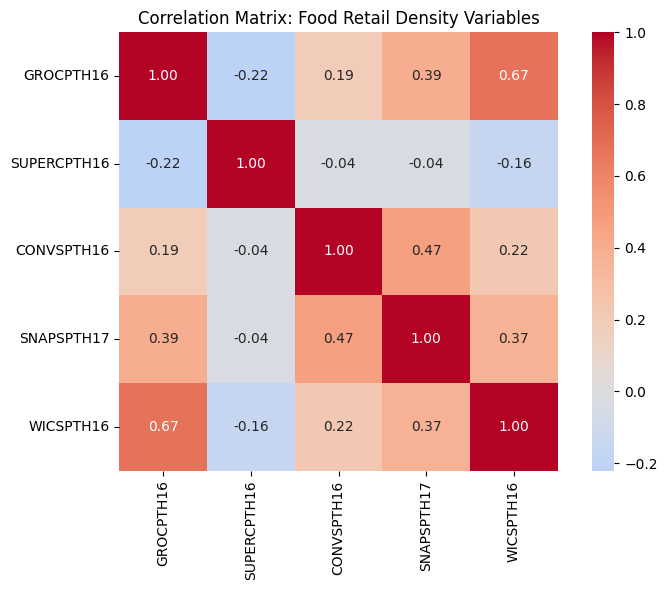

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = stores_clean[density_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix: Food Retail Density Variables")
plt.tight_layout()
plt.show()

Datatype validation

In [67]:
stores_clean.dtypes

,0
FIPS,object
State,object
County,object
GROCPTH16,float64
SUPERCPTH16,float64
CONVSPTH16,float64
SNAPSPTH17,float64
WICSPTH16,float64
FoodInfrastructureIndex,float64


In [68]:
density_cols = [
    "GROCPTH16",
    "SUPERCPTH16",
    "CONVSPTH16",
    "SNAPSPTH17",
    "WICSPTH16"
]

stores_clean[density_cols] = stores_clean[density_cols].apply(pd.to_numeric)

In [69]:
stores_clean[density_cols].min()

,0
GROCPTH16,0.000000
SUPERCPTH16,0.000000
CONVSPTH16,0.000000
SNAPSPTH17,0.040180
WICSPTH16,0.004938


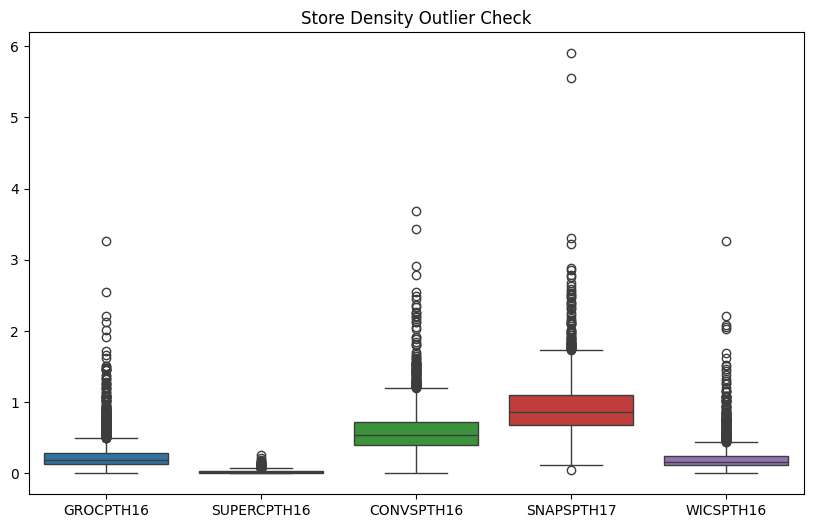

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=stores_clean[density_cols])
plt.title("Store Density Outlier Check")
plt.show()

In [71]:
import numpy as np

log_cols = [
    "GROCPTH16",
    "SUPERCPTH16",
    "CONVSPTH16",
    "SNAPSPTH17",
    "WICSPTH16"
]

for col in log_cols:
    stores_clean[f"log_{col}"] = np.log1p(stores_clean[col])

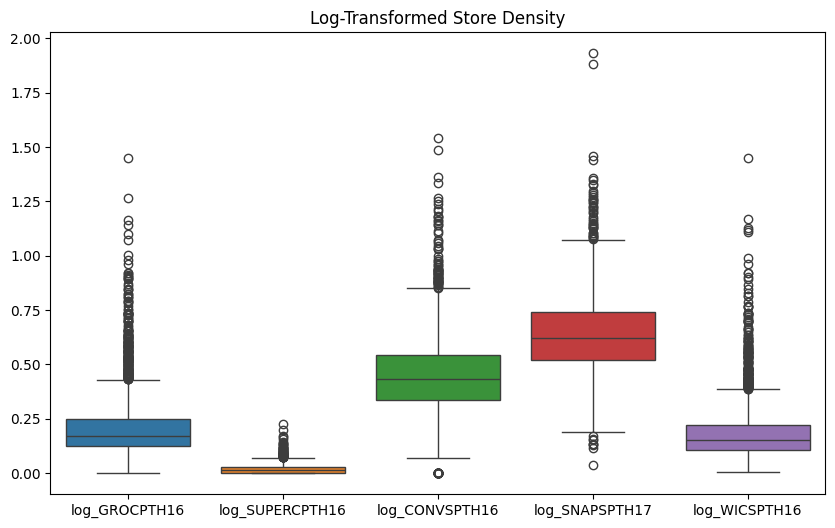

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=stores_clean[[f"log_{c}" for c in log_cols]])
plt.title("Log-Transformed Store Density")
plt.show()

In [73]:
for col in log_cols:
    upper = stores_clean[col].quantile(0.99)
    stores_clean[col] = stores_clean[col].clip(upper=upper)

In [74]:
stores_clean["FoodInfrastructureIndex"] = (
    stores_clean["GROCPTH16"] +
    stores_clean["SUPERCPTH16"] +
    stores_clean["SNAPSPTH17"]
) / 3

In [75]:
import plotly.express as px

fig = px.histogram(
    stores_clean,
    x="FoodInfrastructureIndex",
    nbins=60,
    title="Distribution of Food Infrastructure Index Across Counties"
)

fig.show()

In [76]:
stores_clean["FIPS"] = stores_clean["FIPS"].astype(str).str.zfill(5)

In [77]:
stores_clean["FIPS"].head()

,FIPS
0,01001
1,01003
2,01005
3,01007
4,01009


In [78]:
stores_clean.columns = stores_clean.columns.str.strip()

In [79]:
stores_clean.isnull().sum()

,0
FIPS,0
State,0
County,0
GROCPTH16,0
SUPERCPTH16,0
CONVSPTH16,0
SNAPSPTH17,0
WICSPTH16,0
FoodInfrastructureIndex,0
log_GROCPTH16,0


In [80]:
import os

os.makedirs("/content/drive/MyDrive/data mining/cleaned", exist_ok=True)

In [81]:
stores_clean.to_csv(
    "/content/drive/MyDrive/data mining/cleaned/food_environment_clean.csv",
    index=False
)

In [82]:
import pandas as pd

test = pd.read_csv("/content/drive/MyDrive/data mining/cleaned/food_environment_clean.csv")
test.head()

,FIPS,State,County,GROCPTH16,SUPERCPTH16,CONVSPTH16,SNAPSPTH17,WICSPTH16,FoodInfrastructureIndex,log_GROCPTH16,log_SUPERCPTH16,log_CONVSPTH16,log_SNAPSPTH17,log_WICSPTH16
0,1001,AL,Autauga,0.054271,0.018090,0.560802,0.804747,0.090511,0.292369,0.052850,0.017929,0.445200,0.590420,0.086646
1,1003,AL,Baldwin,0.139753,0.033733,0.568650,0.890836,0.134802,0.354774,0.130812,0.033177,0.450215,0.637019,0.126458
2,1005,AL,Barbour,0.155195,0.038799,0.737177,1.424614,0.232387,0.539536,0.144269,0.038065,0.552261,0.885672,0.208953
3,1007,AL,Bibb,0.220916,0.044183,0.662749,0.801423,0.221474,0.355508,0.199602,0.043235,0.508472,0.588577,0.200058
4,1009,AL,Blount,0.086863,0.017373,0.469059,0.692374,0.139089,0.265536,0.083295,0.017223,0.384622,0.526132,0.130229


In [83]:
viz_dataset2 = stores_clean[[
    "FIPS",
    "State",
    "County",
    "GROCPTH16",
    "SUPERCPTH16",
    "CONVSPTH16",
    "SNAPSPTH17",
    "WICSPTH16",
    "FoodInfrastructureIndex"
]]

viz_dataset2.to_csv(
    "/content/drive/MyDrive/data mining/cleaned/food_environment_viz.csv",
    index=False
)

##Raw dataset viz

In [84]:
import plotly.express as px

fig = px.histogram(
    stores,
    x="GROCPTH16",
    nbins=70,
    title="Raw Distribution of Grocery Store Density Across Counties",
)

fig.show()

In [85]:
fig = px.histogram(
    stores,
    x="SNAPSPTH17",
    nbins=70,
    title="Raw Distribution of SNAP Retailer Density",
)

fig.show()

In [86]:
fig = px.scatter(
    stores,
    x="GROCPTH16",
    y="CONVSPTH16",
    opacity=0.5,
    title="Raw Grocery vs Convenience Store Density"
)

fig.show()

In [87]:
fig = px.histogram(
    stores,
    x="SUPERCPTH16",
    nbins=60,
    title="Distribution of Supercenter Density"
)

fig.show()

In [88]:
import pandas as pd

infra = pd.DataFrame({
    "Type": ["Grocery", "Supercenter", "Convenience", "SNAP Retailers"],
    "Average Density": [
        stores["GROCPTH16"].mean(),
        stores["SUPERCPTH16"].mean(),
        stores["CONVSPTH16"].mean(),
        stores["SNAPSPTH17"].mean()
    ]
})

fig = px.bar(
    infra,
    x="Type",
    y="Average Density",
    title="Average Retail Food Infrastructure per County"
)

fig.show()

In [89]:
top_snap = stores.nlargest(20, "SNAPSPTH17")

fig = px.bar(
    top_snap,
    x="County",
    y="SNAPSPTH17",
    title="Counties with the Highest SNAP Retailer Density"
)

fig.show()

##Cleaned viz

In [90]:
fig = px.histogram(
    stores_clean,
    x="FoodInfrastructureIndex",
    nbins=60,
    title="Distribution of Food Infrastructure Index Across Counties"
)

fig.show()

In [91]:
import json
import urllib.request

with urllib.request.urlopen(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
) as response:
    counties = json.load(response)

fig = px.choropleth(
    stores_clean,
    geojson=counties,
    locations="FIPS",
    featureidkey="id",
    color="FoodInfrastructureIndex",
    color_continuous_scale="Viridis",
    scope="usa",
)

fig.update_layout(title="Food Infrastructure Availability Across U.S. Counties")

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [92]:
fig = px.scatter(
    stores_clean,
    x="GROCPTH16",
    y="CONVSPTH16",
    opacity=0.5,
    title="Healthy vs Convenience Food Retail Environment"
)

fig.show()

In [93]:
fig = px.scatter(
    stores_clean,
    x="SNAPSPTH17",
    y="GROCPTH16",
    opacity=0.5,
    title="SNAP Retailers vs Grocery Store Density"
)

fig.show()

In [94]:
sorted_infra = stores_clean.sort_values("FoodInfrastructureIndex")

sorted_infra["cum_counties"] = range(len(sorted_infra))

fig = px.line(
    sorted_infra,
    x="cum_counties",
    y="FoodInfrastructureIndex",
    title="Inequality in Food Infrastructure Across Counties"
)

fig.show()

We engineer a ratio feature to flag counties where convenience stores dominate the food retail landscape — a proxy for "food desert" conditions.

> **Formula:** `ConvenienceDominance = CONVSPTH16 / (GROCPTH16 + 0.01)`

A small epsilon (0.01) prevents division-by-zero in counties with zero grocery stores.

In [95]:
stores_clean["ConvenienceDominance"] = (
    stores_clean["CONVSPTH16"] /
    (stores_clean["GROCPTH16"] + 0.01)
)

fig = px.histogram(
    stores_clean,
    x="ConvenienceDominance",
    nbins=60,
    title="Counties Where Convenience Stores Dominate Food Retail"
)

fig.show()

In [96]:
state_infra = stores_clean.groupby("State")["FoodInfrastructureIndex"].mean().reset_index()